<a href="https://colab.research.google.com/github/shrouksweid/Self-Balancing-Robot/blob/main/Tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics supervision opencv-python-headless -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 17.4 MB/s eta 0:00:00


In [17]:
from ultralytics import YOLO
import supervision as sv
from collections import defaultdict
import numpy as np
import cv2

#  load  model
model = YOLO("detection.pt")
tracker = sv.ByteTrack()
box_ann = sv.BoxAnnotator(thickness=2)
lbl_ann = sv.LabelAnnotator(text_scale=0.5)

#  import kalman + features from the file ──
import importlib.util, sys
spec = importlib.util.spec_from_file_location("aegis", "aegis_tracker.py")
aegis = importlib.util.module_from_spec(spec)
spec.loader.exec_module(aegis)

DroneKalmanFilter  = aegis.DroneKalmanFilter
TrajectoryFeatures = aegis.TrajectoryFeatures
compute_threat_score = aegis.compute_threat_score
THREAT_COLORS      = aegis.THREAT_COLORS
draw_trail         = aegis.draw_trail
draw_track_box     = aegis.draw_track_box

print("All imports OK")

All imports OK


In [15]:
!pip install yt-dlp -q
!yt-dlp -f "best[ext=mp4][height<=720]" "https://www.youtube.com/shorts/JQ9PLGlJ6vU" -o "drone_test.mp4"

[youtube] Extracting URL: https://www.youtube.com/shorts/JQ9PLGlJ6vU
[youtube] JQ9PLGlJ6vU: Downloading webpage
[youtube] JQ9PLGlJ6vU: Downloading android vr player API JSON
[info] JQ9PLGlJ6vU: Downloading 1 format(s): 18
[download] Destination: drone_test.mp4
[download] 100% of  427.08KiB in 00:00:00 at 1.45MiB/s


In [16]:
INPUT_VIDEO  = "drone_test.mp4"
OUTPUT_VIDEO = "aegis_output.mp4"

cap = cv2.VideoCapture(INPUT_VIDEO)
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS = cap.get(cv2.CAP_PROP_FPS) or 30

writer = cv2.VideoWriter(OUTPUT_VIDEO,
           cv2.VideoWriter_fourcc(*"mp4v"), FPS, (W, H))

kalman_filters = {}
trajectories   = defaultdict(list)
feat_extractor = TrajectoryFeatures((W//2, H//2))
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results    = model(frame, imgsz=512, conf=0.35, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = tracker.update_with_detections(detections)

    for i, tid in enumerate(detections.tracker_id):
        x1,y1,x2,y2 = detections.xyxy[i]
        cx,cy = (x1+x2)/2, (y1+y2)/2
        if tid not in kalman_filters:
            kalman_filters[tid] = DroneKalmanFilter(cx, cy)
        kf = kalman_filters[tid]
        kf.predict()
        kf.update(cx, cy)
        trajectories[tid].append((cx, cy))
        if len(trajectories[tid]) > 60:
            trajectories[tid].pop(0)

    for i, tid in enumerate(detections.tracker_id):
        kf       = kalman_filters[tid]
        features = feat_extractor.compute(trajectories[tid])
        score, label = compute_threat_score(features, W, H)
        color    = THREAT_COLORS.get(label, (200,200,200))
        draw_trail(frame, trajectories[tid], color)
        x1,y1,x2,y2 = detections.xyxy[i]
        draw_track_box(frame,x1,y1,x2,y2,tid,score,label,
                       kf.speed,
                       features["behavior"] if features else "MONITORING",
                       False, kf.position_uncertainty)

    writer.write(frame)
    frame_idx += 1
    if frame_idx % 30 == 0:
        print(f"  Processed {frame_idx} frames...")

cap.release()
writer.release()
print(f"Done! Saved to {OUTPUT_VIDEO}")

  Processed 30 frames...
  Processed 60 frames...
  Processed 90 frames...
  Processed 120 frames...
  Processed 150 frames...
  Processed 180 frames...
  Processed 210 frames...
  Processed 240 frames...
  Processed 270 frames...
Done! Saved to aegis_output.mp4


In [18]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open("aegis_output.mp4","rb").read()
data = b64encode(mp4).decode()
HTML(f'<video width="800" controls><source src="data:video/mp4;base64,{data}"></video>')


0: 512x288 8 drones, 90.7ms
Speed: 4.3ms preprocess, 90.7ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 288)


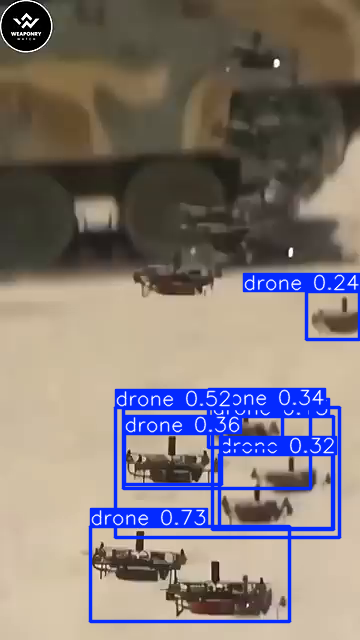

Detections found: 8
Confidence scores: [0.7263278365135193, 0.5236235857009888, 0.35884371399879456, 0.3434336185455322, 0.3229694962501526, 0.24055831134319305, 0.15090425312519073, 0.12684321403503418]


In [19]:
from ultralytics import YOLO
import cv2

model = YOLO("detection.pt")

# grab one frame from the video
cap = cv2.VideoCapture("drone_test.mp4")
ret, frame = cap.read()
cap.release()

# run detection and show result
results = model(frame, imgsz=512, conf=0.1)  # conf=0.1 = very sensitive
results[0].show()  # displays the frame with boxes drawn

print("Detections found:", len(results[0].boxes))
print("Confidence scores:", results[0].boxes.conf.tolist())